In [45]:
# Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_log_error

In [33]:
# Load data
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [46]:
# Feature engineering
for df in [train, test]:
    df["Shell_ratio"] = df["Shell weight"] / (df["Whole weight"] + 1e-6)

    df["Length_Diameter_ratio"] = df["Length"] / (df["Diameter"] + 1e-6)

    df["Volume"] = df["Length"] * df["Diameter"] * df["Height"]

    df["Density"] = df["Whole weight"] / (df["Volume"] + 1e-6)

In [47]:
# Defining X and y
X = train.drop(columns=["Rings"])
y = train["Rings"]

# Log transform target
y_log = np.log1p(y)

X_test_final = test.copy()

In [48]:
# Train validation split using LOG target
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=42
)

In [49]:
# Preprocessing
categorical_features = ["Sex"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [50]:
# Polynomial Ridge Regression model
poly_model = Pipeline([
    ("preprocessor", preprocessor),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(
        degree=2,
        include_bias=False
    )),
    ("regressor", Ridge(alpha=10))
])

In [51]:
# Fit model
poly_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Sex'])])),
                ('scaler', StandardScaler()),
                ('poly', PolynomialFeatures(include_bias=False)),
                ('regressor', Ridge(alpha=10))])

In [52]:
# Predict validation set
preds_log = poly_model.predict(X_valid)

# Convert predictions back to original Rings scale
preds = np.expm1(preds_log)

# Remove negative predictions
preds = np.maximum(preds, 0)

# Convert y_valid back to original Rings scale
y_valid_original = np.expm1(y_valid)

# Calculate RMSLE
rmsle = np.sqrt(
    mean_squared_log_error(
        y_valid_original,
        preds
    )
)

print("Polynomial Ridge RMSLE:", rmsle)

Polynomial Ridge RMSLE: 0.15788134501878223


In [53]:
# Train final model on full dataset
poly_model.fit(X, y_log)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Sex'])])),
                ('scaler', StandardScaler()),
                ('poly', PolynomialFeatures(include_bias=False)),
                ('regressor', Ridge(alpha=10))])

In [54]:
# Predict Kaggle test set
test_preds_log = poly_model.predict(X_test_final)

test_predictions = np.expm1(test_preds_log)

test_predictions = np.maximum(test_predictions, 0)

In [55]:
# Create submission file
submission = pd.DataFrame({
    "id": test["id"],
    "Rings": test_predictions
})

submission.to_csv("polynomial_ridge_submission.csv", index=False)

submission.head()

,id,Rings
0,90615,9.249203
1,90616,9.605884
2,90617,10.275101
3,90618,9.972984
4,90619,7.567847


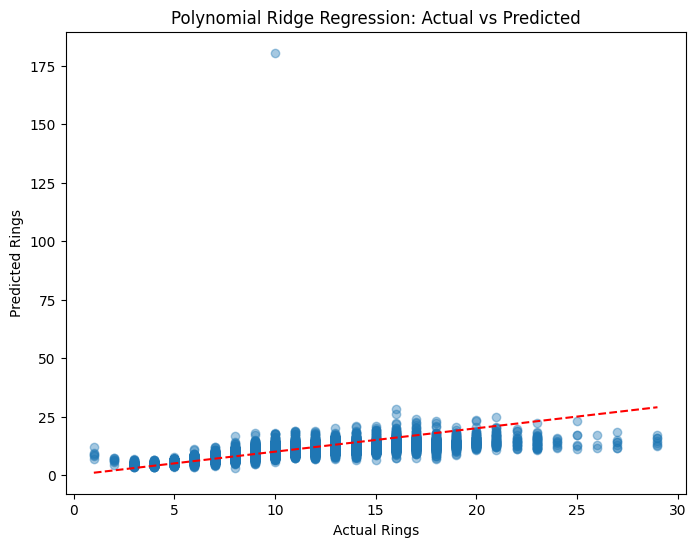

In [56]:
# Actual vs Predicted Values
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_valid_original,
    preds,
    alpha=0.4
)

plt.plot(
    [y_valid_original.min(), y_valid_original.max()],
    [y_valid_original.min(), y_valid_original.max()],
    'r--'
)

plt.xlabel("Actual Rings")
plt.ylabel("Predicted Rings")
plt.title("Polynomial Ridge Regression: Actual vs Predicted")

plt.show()

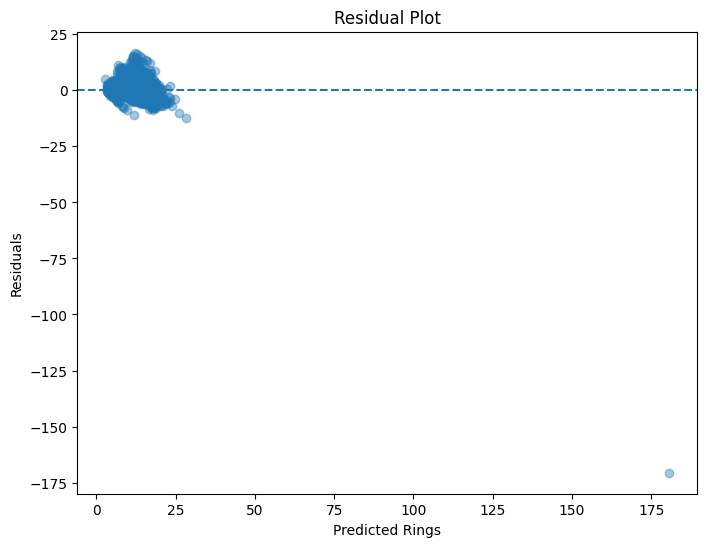

In [57]:
# Residual plot
residuals = y_valid_original - preds

plt.figure(figsize=(8,6))

plt.scatter(
    preds,
    residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Rings")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

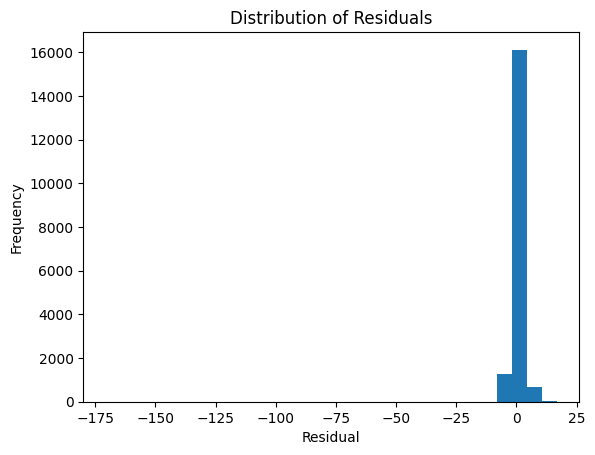

In [58]:
# Histogram of residualsplt.figure(figsize=(8,6))

plt.hist(
    residuals,
    bins=30
)

plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.title("Distribution of Residuals")

plt.show()

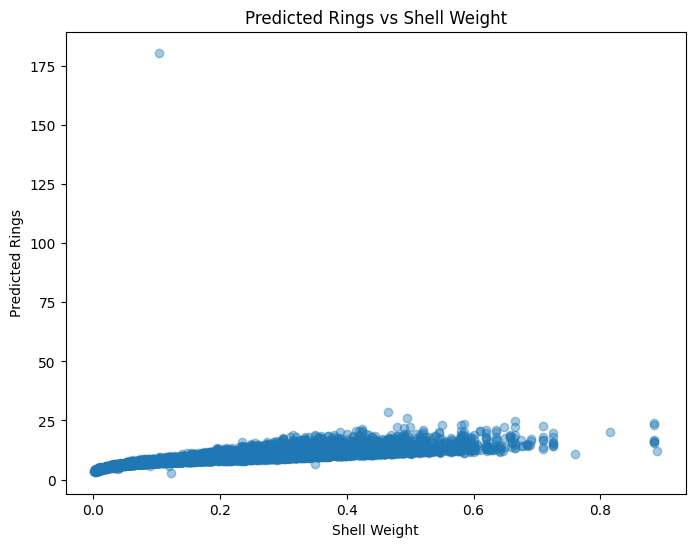

In [59]:
# Predicted vs shell weight
plt.figure(figsize=(8,6))

plt.scatter(
    X_valid["Shell weight"],
    preds,
    alpha=0.4
)

plt.xlabel("Shell Weight")
plt.ylabel("Predicted Rings")

plt.title("Predicted Rings vs Shell Weight")

plt.show()